In [5]:
import tensorflow as tf
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\home1\Downloads\pythondev\dog_cat_photos\train",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=True
)
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\home1\Downloads\pythondev\dog_cat_photos\test",
    image_size=(224, 224),
    label_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 300 files belonging to 2 classes.


Found 100 files belonging to 2 classes.


In [8]:
def flip_left_right(image, label):   # 左右反転
    image = tf.image.flip_left_right(image)
    return image, label

def flip_up_down(image, label):      # 上下反転
    image = tf.image.flip_up_down(image)
    return image, label

def rot90(image, label):             # 反時計回りに90度回転
    image = tf.image.rot90(image)
    return image, label

def rot180(image, label):            # 反時計回りに180度回転
    image = tf.image.rot90(image, k=2)
    return image, label

def rot270(image, label):            # 反時計回りに270度回転
    image = tf.image.rot90(image, k=3)
    return image, label

In [10]:
train_dataset_lr     = train_dataset.map(flip_left_right)
train_dataset_ud     = train_dataset.map(flip_up_down)
train_dataset_rot90  = train_dataset.map(rot90)
train_dataset_rot180 = train_dataset.map(rot180)
train_dataset_rot270 = train_dataset.map(rot270)

train_dataset = train_dataset.concatenate(train_dataset_lr)
train_dataset = train_dataset.concatenate(train_dataset_ud)
train_dataset = train_dataset.concatenate(train_dataset_rot90)
train_dataset = train_dataset.concatenate(train_dataset_rot180)
train_dataset = train_dataset.concatenate(train_dataset_rot270)

C:\Users\home1\AppData\Local\Temp\ipykernel_11868\1084042432.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(labels[i].numpy())


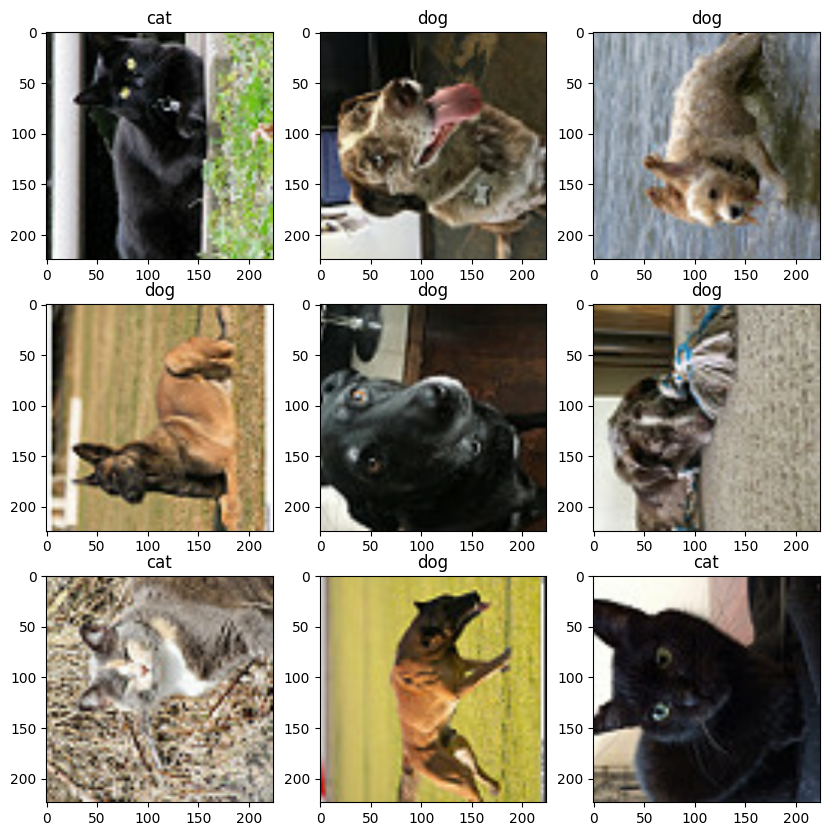

In [22]:
import matplotlib.pyplot as plt
class_names = ["cat", "dog"]

train_dataset = train_dataset.shuffle(1000)

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label = int(labels[i].numpy())
        plt.title(class_names[label])

In [23]:
# MobileNetV2モデルを作成する
input_layer = tf.keras.Input(shape=(224, 224, 3))   # 入力層
l_layer = tf.keras.applications.mobilenet_v2.preprocess_input(input_layer)   # 前処理層

base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(
    input_shape=(224, 224, 3),
    input_tensor=l_layer,
    include_top=False,
    weights="imagenet",
    pooling='avg'
)

base_model.trainable = False

In [24]:
# Dense層を追加する
output_layer = tf.keras.layers.Dense(1, activation='sigmoid')

In [25]:
model = tf.keras.Sequential([
    base_model,
    output_layer
])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
model.compile(optimizer="adam",
              loss='binary_crossentropy',
              metrics=["accuracy"])

In [28]:
model.fit(train_dataset, epochs=20)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 37s 468ms/step - accuracy: 0.8239 - loss: 0.4013
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 448ms/step - accuracy: 0.9222 - loss: 0.2135
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 450ms/step - accuracy: 0.9483 - loss: 0.1615
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 453ms/step - accuracy: 0.9622 - loss: 0.1335
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 450ms/step - accuracy: 0.9728 - loss: 0.1128
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 451ms/step - accuracy: 0.9744 - loss: 0.0967
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 449ms/step - accuracy: 0.9794 - loss: 0.0870
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 449ms/step - accuracy: 0.9844 - loss: 0.0768
Epoch 9/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 447ms/step - accuracy: 0.9878 - loss: 0.0691
Epoch 10/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28s 450ms/step - accuracy: 0.9900 - loss: 0.0627
Epoch 11/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 29s 461ms/step - accuracy: 0.9922 - loss: 0.0576
Epoch 12/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 28

In [29]:
model.evaluate(test_dataset)

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 396ms/step - accuracy: 0.9700 - loss: 0.0742


[0.0741952583193779, 0.9700000286102295]